In [2]:
import pocam_light
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import hephaistos as hp
#hp.selectDevice(0)
import hephaistos.pipeline as pl
from theia.volume import Attenuating
import theia
import theia.units as u
from pathlib import Path
from theia.compiler import addIncludeDir
addIncludeDir(Path("shader"))

In [63]:
class MediumModel(                                    
    theia.material.HenyeyGreensteinPhaseFunction,  #in welche Richtung fliegt ein Photon nachdem es gestreut wurde
    theia.material.DispersionFreeMedium,           # Wellenlänge unabh. von Brechungsindex
):
    def __init__(self):                            #Initialisierung und optische Eigenschaften des Eises
        super().__init__(
            n=1.15,                                #Brechungsindex
            ng=1.35,                               #Gruppenbrechungsindex: definiert 
                                                   #Geschwindigkeit eines Lichtpulses v_g = c/n_g
            mu_a=  0.04121681 / u.m,               #Absorptionskoeffizient: Nach etwa 24 m hat ein Photon im Mittel eine Überlebenswahrscheinlichkeit von 1/e.
            mu_s=  0.151855 / u.m,
            g=0.9,
            name="Eisschicht",
        )

#Attenuating(): Photonen werden absorbiert, keine Energieerzeugung, keine Fluoreszenz usw.

medium = MediumModel().createMedium(physicModel = Attenuating())
store = theia.material.MaterialStore([], media=[medium])

rng = theia.random.PhiloxRNG(key=0xABBA)
response = theia.response.HistogramHitResponse(
    theia.response.UniformValueResponse(),
    binCount=200,
    binSize= 2.0 * u.ns,
    t0 = 90 * u.ns
)
target = theia.target.SphereTarget(
    position= (31.25, -72.9300003051757, -383.3999938964844) * u.m,
    radius= 0.5 * u.m,
)
wavelength = theia.light.ConstWavelengthSource(405.0 * u.nm)
sharedStages = [target, wavelength, response, rng]

sphereLight = pocam_light.PocamLightSource(wavelength, mediumIdx=store.media["Eisschicht"])
batchSize = 1000000

from theia.ray import UnpolarizedRay

ray = UnpolarizedRay()

#stats = theia.trace.EventStatisticCallback()

sphereTracer = theia.trace.VolumeForwardTracer(
    batchSize,
    ray,
    sphereLight,
    target,
    response,
    rng,
    store,
    volume="Eisschicht",
    #callback=stats, 
    maxPathLength=1000,
    disableTargetSampling=False,
)

spherePipeline = pl.Pipeline(sphereTracer.collectStages())

hists = []
def process(config: int, batch: int, args: None) -> None:
    hists.append(response.result(config).copy())

pipelineMap = {
    "sphere": spherePipeline,
}
scheduler = pl.PipelineScheduler(pipelineMap, processFn=process)


tasks = [
    ("sphere", {
        "lightSource__budget": 1e10,
        "lightSource__position": (46.9072,-56.5889,-385.93) * u.m,
    }),
    ("sphere", {}),
    ("sphere", {}),
    ("sphere", {}),
    ("sphere", {}),
]
# submit work
scheduler.schedule(tasks)
scheduler.wait()

t = (
    np.arange(response.binCount) * response.binSize + response.t0
) / u.ns

sphereSignal = np.mean(hists[:50], 0)
sphereSignalNorm = sphereSignal / (
    np.sum(sphereSignal) * response.binSize / u.ns
)
print(np.sum(sphereSignal))
#print(stats)

517835.1381906219


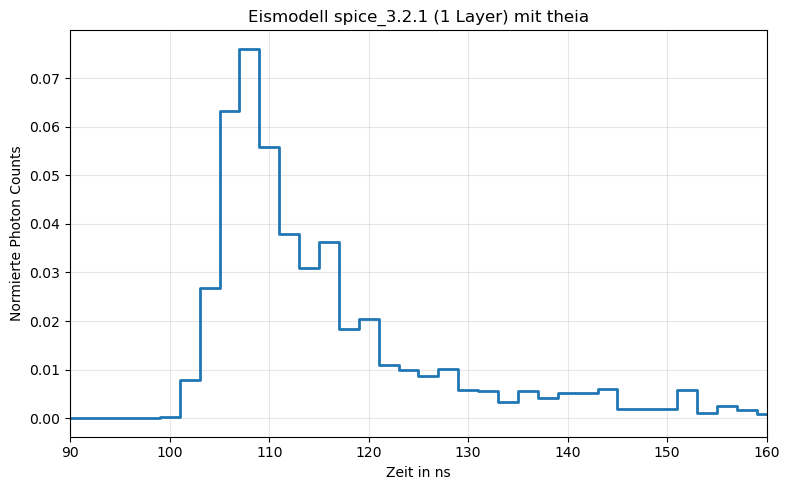

In [64]:
plt.figure(figsize=(8,5))
plt.step(
    t,
    sphereSignalNorm,
    where="mid",
    linewidth=2,
    label="Spherical source"
)

plt.xlabel("Zeit in ns")
plt.ylabel("Normierte Photon Counts")
plt.title(r"Eismodell spice_3.2.1 (1 Layer) mit theia")
#plt.yscale("log")
plt.grid(True, alpha=0.3)
plt.xlim(90,160)

plt.tight_layout()
plt.savefig("withscattering_onelayer.pdf")


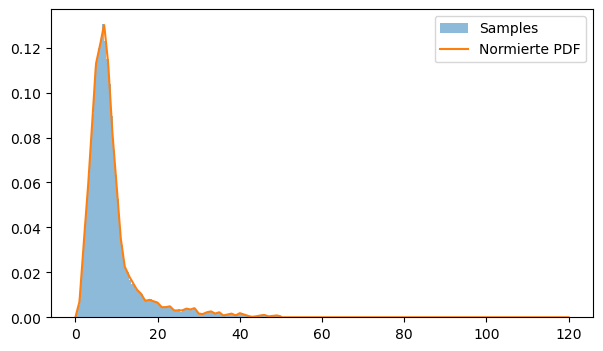

In [65]:
# Test, ob NumericalInversePolynomial die richtige Wahrscheinlichkeitsverteilung samplet

from scipy.stats.sampling import NumericalInversePolynomial
import numpy as np
import matplotlib.pyplot as plt
from pocam_light import _the_pulse

class Dist:
    def pdf(self, x):
        return _the_pulse(x, 15.0) 
                                   #NumericalInversePolynomial() erwartet nämlich ein Objekt das von Dist() erzeugt
                                   #wird und eine Methode pdf(x) besitzt

inv_cdf = NumericalInversePolynomial(
    Dist(),
    domain=(0.0, 120.0),              #erwartet ein Objekt mit Mehode
)
samples = inv_cdf.rvs(size=100000)

plt.figure(figsize=(7,4))

x = np.linspace(0,120,1000)

pdf = _the_pulse(x, 15)
pdf /= np.trapezoid(pdf, x)   # Nomirern!!

plt.hist(samples, bins=100, density=True, alpha=0.5, label="Samples") # density= TRue zur Normierung
plt.plot(x, pdf, label="Normierte PDF")

plt.legend()
plt.show()

In [ ]:
#Test, ob die Pocam-Lightsource funktioniert und Vergl. der Zeiten mit den zeiten der pulse_fkt

import pytest

import numpy as np
import scipy.integrate as integrate
import scipy.stats as stats

import hephaistos as hp
from hephaistos.pipeline import Pipeline, PipelineScheduler, runPipeline
from hephaistos.queue import dumpQueue
from ctypes import Structure, c_float

import theia.light
import theia.units as u
from theia.compiler import compileShader
from theia.material import MaterialStore, PureWaterModel, VACUUM_IDX
from theia.random import PhiloxRNG
from theia.ray import UnpolarizedRay
from theia.testing import BackwardLightSampler

N = 32 * 256
position = (14.0, -2.0, 3.0) * u.m
budget = 12.0

ray = UnpolarizedRay()
philox = PhiloxRNG(key=0xC0110FFC0FFEE)

photons = theia.light.ConstWavelengthSource(
    wavelength=100.0 * u.nm
)

light = pocam_light.PocamLightSource(
    photons,
    position=position,
    budget=budget,
    mediumIdx=VACUUM_IDX,
)

sampler = theia.light.LightSampler(
    N,
    light,
    ray,
    rng=philox,
)

runPipeline(sampler.collectStages())

result = sampler.queue.view(0)

plt.figure(figsize=(8,5))
plt.hist(times, bins=100, density=True, alpha=0.5, label="PocamLightSource")

x = np.linspace(0,120,1000)
pdf = _the_pulse(x,15)
pdf /= np.trapezoid(pdf, x)

plt.plot(x, pdf, lw=2, label=" _the_pulse (normiet)")

plt.legend()
plt.show()


In [ ]:
!git --version